# Technical Indicators Analysis

Calculate and visualize technical indicators.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
# Add project root to path so `src` is importable from the notebook
sys.path.append('..')

from src.utils.config import DEFAULT_TICKERS, RAW_DATA_DIR
from src.preprocessing.feature_engineering import add_technical_indicators, add_price_features, create_lag_features

%matplotlib inline

In [2]:
%pip install pandas_ta --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import pandas_ta as ta
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))
from src.data_collection.load_kaggle_data import load_kaggle_data
from src.preprocessing.clean_data import clean_ohlcv_data
from src.utils.config import DEFAULT_TICKERS

# Load sample ticker
ticker = DEFAULT_TICKERS[0]
print(f"Loading {ticker}...")
raw_data = load_kaggle_data(ticker)
data = clean_ohlcv_data(raw_data)

print(f"Data shape: {data.shape}")
print(f"Date range: {data.index[0]} to {data.index[-1]}")

# Add technical indicators
print("\nAdding technical indicators...")

# Moving averages
data['SMA_20'] = ta.sma(data['Close'], length=20)
data['SMA_50'] = ta.sma(data['Close'], length=50)
data['EMA_12'] = ta.ema(data['Close'], length=12)
data['EMA_26'] = ta.ema(data['Close'], length=26)

# RSI
data['RSI'] = ta.rsi(data['Close'], length=14)

# MACD
macd = ta.macd(data['Close'])
data = pd.concat([data, macd], axis=1)

# Bollinger Bands
bb = ta.bbands(data['Close'], length=20)
data = pd.concat([data, bb], axis=1)

# ATR
data['ATR'] = ta.atr(data['High'], data['Low'], data['Close'], length=14)

# Volume SMA
data['Volume_SMA_20'] = ta.sma(data['Volume'], length=20)

# Stochastic Oscillator
stoch = ta.stoch(data['High'], data['Low'], data['Close'])
data = pd.concat([data, stoch], axis=1)

print(f"Added indicators. New shape: {data.shape}")
print(f"Columns: {list(data.columns)}")
print(f"\nFirst few rows with indicators:")
print(data.iloc[-5:][['Close', 'SMA_20', 'SMA_50', 'RSI', 'ATR']])

Loading features from: ..\data\indicators\TCS.NS_features.csv
Loaded features shape: (1127, 39)


,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_12,EMA_26,RSI,...,volatility_20,Close_lag_1,Close_lag_2,Close_lag_3,Volume_lag_1,Volume_lag_2,Volume_lag_3,RSI_lag_1,RSI_lag_2,RSI_lag_3
Price,,,,,,,,,,,,,,,,,,,,,
2024-11-21,3935.940430,3954.881430,3888.732438,3908.929786,2384347,3941.516650,4004.687993,3954.937204,3959.620103,47.519810,...,0.014907,3903.760254,3884.384033,4006.534912,1776233.0,3313944.0,1825432.0,44.028056,41.865444,54.102188
2024-11-22,4101.917480,4111.919659,3917.724422,3934.152966,3096553,3950.134399,4006.527676,3977.549554,3970.160650,61.025070,...,0.017395,3935.940430,3903.760254,3884.384033,2384347.0,1776233.0,3313944.0,47.519810,44.028056,41.865444
2024-11-28,4102.207031,4194.062196,4090.707146,4173.816244,2558544,3959.653284,4008.195210,3996.727627,3979.941863,61.043904,...,0.017331,4101.917480,3935.940430,3903.760254,3096553.0,2384347.0,1776233.0,61.025070,47.519810,44.028056
2024-11-29,4127.285156,4154.199071,4054.612821,4078.144388,2017425,3969.959802,4008.077964,4016.813401,3990.856181,62.724034,...,0.017349,4102.207031,4101.917480,3935.940430,2558544.0,3096553.0,2384347.0,61.043904,61.025070,47.519810
2024-12-02,4132.889648,4144.051677,4087.856020,4126.463284,1670944,3978.937500,4008.155737,4034.671285,4001.377179,63.106980,...,0.017302,4127.285156,4102.207031,4101.917480,2017425.0,2558544.0,3096553.0,62.724034,61.043904,61.025070


In [ ]:
# Compare all tickers indicators
print("\nTechnical Indicators Summary for All Tickers:")
print("="*70)

for ticker in DEFAULT_TICKERS[:3]:  # Show first 3 for brevity
    raw_data = load_kaggle_data(ticker)
    cleaned = clean_ohlcv_data(raw_data)
    
    # Add basic indicators
    cleaned['RSI'] = ta.rsi(cleaned['Close'], length=14)
    cleaned['SMA_20'] = ta.sma(cleaned['Close'], length=20)
    cleaned['SMA_50'] = ta.sma(cleaned['Close'], length=50)
    
    print(f"\n{ticker}:")
    print(f"  Latest Close: {cleaned['Close'].iloc[-1]:.2f}")
    print(f"  Latest RSI: {cleaned['RSI'].iloc[-1]:.2f}")
    print(f"  SMA_20: {cleaned['SMA_20'].iloc[-1]:.2f}")
    print(f"  SMA_50: {cleaned['SMA_50'].iloc[-1]:.2f}")
    print(f"  Volatility (30d): {cleaned['Close'].pct_change().rolling(30).std().iloc[-1]:.4f}")

Available data intervals:
--------------------------------------------------

RELIANCE.NS:
  ✓ 1d: 1 rows in file
  ✓ 5m: 1 rows in file
  ✓ 1m: 1 rows in file

TCS.NS:
  ✓ 1d: 1 rows in file
  ✓ 5m: 1 rows in file
  ✓ 1m: 1 rows in file

INFY.NS:
  ✓ 1d: 1 rows in file
  ✓ 5m: 1 rows in file
  ✓ 1m: 1 rows in file

HDFCBANK.NS:
  ✓ 1d: 1 rows in file
  ✓ 5m: 1 rows in file
  ✓ 1m: 1 rows in file

ICICIBANK.NS:
  ✓ 1d: 1 rows in file
  ✓ 5m: 1 rows in file
  ✓ 1m: 1 rows in file


## Check Available Data Intervals

## Moving Averages

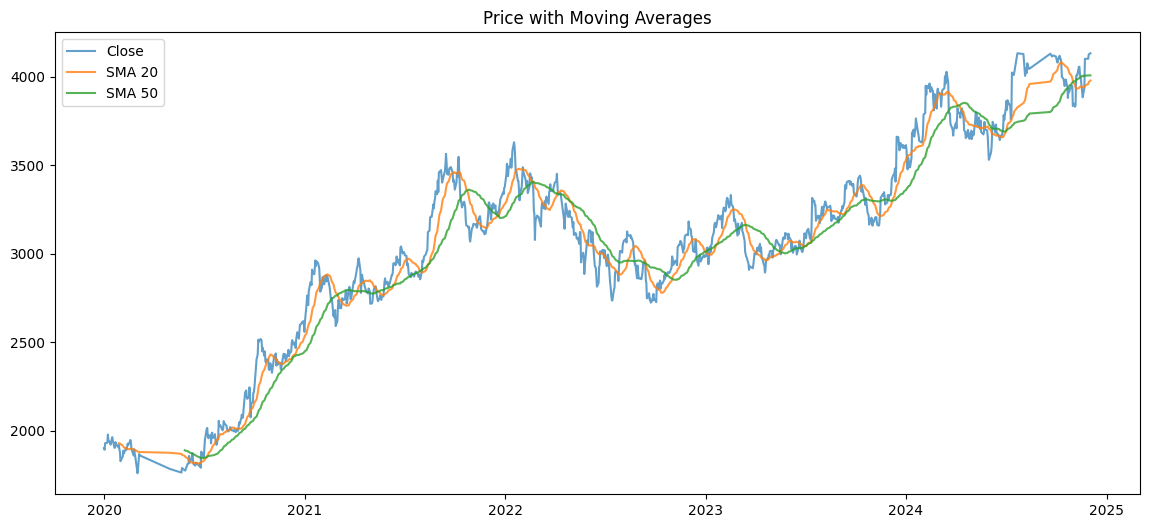

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: Close with Moving Averages
axes[0].plot(data.index, data['Close'], label='Close', linewidth=1)
axes[0].plot(data.index, data['SMA_20'], label='SMA 20', linewidth=1, alpha=0.7)
axes[0].plot(data.index, data['SMA_50'], label='SMA 50', linewidth=1, alpha=0.7)
axes[0].set_title('Close Price with Moving Averages')
axes[0].set_ylabel('Price')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: RSI
axes[1].plot(data.index, data['RSI'], label='RSI', color='purple')
axes[1].axhline(y=30, color='r', linestyle='--', alpha=0.5, label='Oversold')
axes[1].axhline(y=70, color='g', linestyle='--', alpha=0.5, label='Overbought')
axes[1].set_title('RSI (14)')
axes[1].set_ylabel('RSI')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Volume
axes[2].bar(data.index, data['Volume'], width=0.01, alpha=0.5)
axes[2].plot(data.index, data['Volume_SMA_20'], label='Volume SMA 20', color='red', linewidth=1)
axes[2].set_title('Volume with SMA')
axes[2].set_ylabel('Volume')
axes[2].set_xlabel('Date')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## RSI

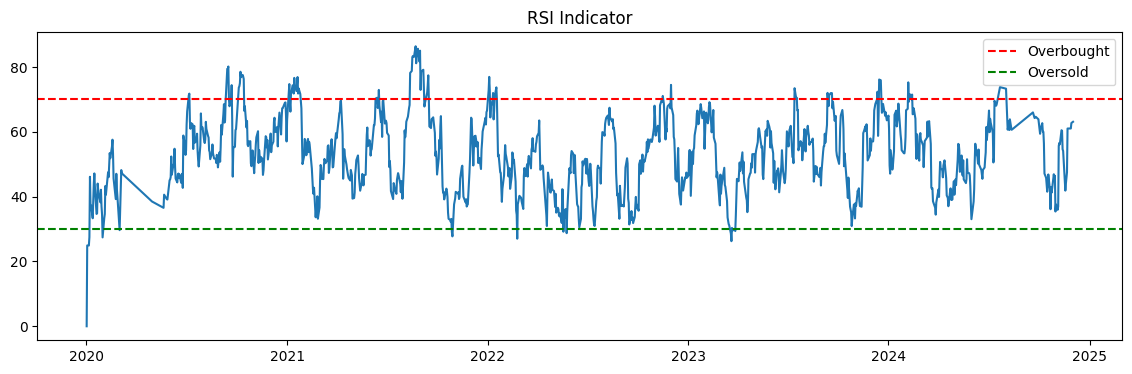

In [ ]:
# Correlation heatmap
import numpy as np

indicator_cols = ['Close', 'SMA_20', 'SMA_50', 'RSI', 'ATR', 'Volume']
corr_matrix = data[indicator_cols].corr()

plt.figure(figsize=(8, 6))
import seaborn as sns
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Technical Indicators')
plt.tight_layout()
plt.show()

print("\nCorrelation Matrix:")
print(corr_matrix)